# 602 — one cell, one def


inside the module, so a crash costs you one cell, not the whole notebook.

In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import sys
sys.path.insert(0, "")          # this folder, so pipe_502 imports
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))  # only path this notebook sets; A_Config adds the rest on import
from ZZ_MASTER_SWITCH_PYTHON import *
case_name = "602_ManU_ref"
experiment = "Pipe_eval_01"
from A_Config import set_case
set_case(case_name, experiment)
timer_start()

## RESTART HERE

Kernel died? Run this one cell. It re-derives config, paths, the Producer's flags,
the paper edit, the recon jobs, every solved reconstruction and the GPS calibration —
without re-running Gemini, ASR, SAM3, the Producer agent or a VGGT solve.

Not restored (they cost money or a GPU): `reid_match()`, `subject_positions()`.

# Config

In [2]:
config(case_name, experiment)

project_root: /workspace/project
Case    : 602_ManU_ref
Video   : 602.mp4
video fps: 30.000
total_frames 3739


{'case_name': '602_ManU_ref',
 'experiment': 'Pipe_eval_01',
 'project_root': PosixPath('/workspace/project'),
 'case_dir': PosixPath('/workspace/project/Data/602_ManU_ref'),
 'source_dir': PosixPath('/workspace/project/Data/602_ManU_ref/010_source'),
 'query_dir': PosixPath('/workspace/project/Data/602_ManU_ref/012_Gemini_outputs'),
 'masks_dir': PosixPath('/workspace/project/Data/602_ManU_ref/015_SAM3_masks/Pipe_eval_01'),
 'frames_for_cam_poses': PosixPath('/workspace/project/Data/602_ManU_ref/020_frames_for_cam_poses/Pipe_eval_01'),
 'frames_for_recon': PosixPath('/workspace/project/Data/602_ManU_ref/020_frames_for_recon/Pipe_eval_01'),
 'VGGT_O_output_dir': PosixPath('/workspace/project/Data/602_ManU_ref/035_VGGT_O_output/Pipe_eval_01'),
 'ply_dir': PosixPath('/workspace/project/Data/602_ManU_ref/035_VGGT_O_output/Pipe_eval_01/ply'),
 'reg_dir': PosixPath('/workspace/project/Data/602_ManU_ref/030_Registrations/Pipe_eval_01'),
 'csv_path_GPS': PosixPath('/workspace/project/Data/602

In [3]:
set_flags()

{'VID_TO_TEXT': True, 'TRACKING': False, 'FRAME_SELECTION': True, 'RECON_CAM_POSES': False, 'RECON_3D': False, 'GOOGLE_MAP': False, 'BEV_MAP': True, 'PROJECTION': False, 'MAKE_MOVIE': False, 'MAKE_MOVIE_CUTS': False, 'MASK_OVERLAYS': False, 'PHYSICS_OVERLAYS': False, 'MULTICAM': False}


{'TRACKING': False,
 'RECON_CAM_POSES': False,
 'RECON_3D': False,
 'GOOGLE_MAP': False,
 'BEV_MAP': True,
 'PROJECTION': False,
 'MASK_OVERLAYS': False,
 'MULTICAM': False}

# AI First Pass

In [4]:
gps()

{'GPS_signal': 'no'}


{'GPS_signal': 'no'}

In [5]:
vid_to_text()

uploading video
re_caching video
[gemini-diag] video duration 02:04, 1 windows for summary/transcript
Here is a detailed summary of the events in the video clip, broken down by key moments:

00:00 - 00:13: The referee conducts the pre-match coin toss with captains Cuti Romero and Bruno Fernandes, setting a collaborative tone by encouraging them to communicate throughout the game.

00:13 - 00:31: The referee follows a quick attack, confirms a clean tackle, and shares a lighthearted moment with a player who just missed a scoring chance.

00:31 - 00:41: The referee keeps up with the fast-paced play, making quick and decisive calls for goal kicks as the ball goes out of bounds.

00:41 - 01:09: A critical moment occurs when Bruno Fernandes makes a high, forceful tackle on James Maddison. The referee immediately stops play, issues a red card, and explains his reasoning to the protesting players.

01:09 - 01:20: The referee monitors another challenge, confidently ruling that the defender clea

In [6]:
# people()

In [7]:
transcript()

/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[asr] extracting audio from 602.mp4
[asr] 23 speech regions, 1.6 min of speech
[asr] whisper large-v3 on cuda
[asr]   ...00:00
[asr] 241 words (0 dropped as non-speech) -> 602_ManU_ref_Pipe_eval_01_asr_words.json
[asr] reusing 602_ManU_ref_Pipe_eval_01_audio16k.wav
[asr] diarizing with pyannote/speaker-diarization-3.1


/home/vscode/.local/lib/python3.11/site-packages/pyannote/audio/utils/reproducibility.py:74: ReproducibilityWarning: TensorFloat-32 (TF32) has been disabled as it might lead to reproducibility issues and lower accuracy.
It can be re-enabled by calling
   >>> import torch
   >>> torch.backends.cuda.matmul.allow_tf32 = True
   >>> torch.backends.cudnn.allow_tf32 = True
See https://github.com/pyannote/pyannote-audio/issues/1370 for more details.

  warnings.warn(
/home/vscode/.local/lib/python3.11/site-packages/pyannote/audio/models/blocks/pooling.py:104: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1831.)
  std = sequences.std(dim=-1, correction=1)


[asr] 40 turns, 2 speakers
[asr] reusing 602_ManU_ref_Pipe_eval_01_audio16k.wav


Loading weights: 100%|██████████| 203/203 [00:00<00:00, 9144.30it/s]

[asr] tagging audio events with ast-finetuned-audioset-10-10-0.4593


[asr] 0 audio events (0 vocal) -> 602_ManU_ref_Pipe_eval_01_audio_events.json
[asr] 16 utterances + 0 events -> /workspace/project/Data/602_ManU_ref/013_ASR_outputs/602_ManU_ref_Pipe_eval_01_transcript_asr.txt
**00:00-00:03** [SPEAKER_00]: Courtney, red or silver? Red. It is a red.

**00:07-00:10** [SPEAKER_00]: Just talk, I'll explain everything, but just talk together, okay?

**00:21-00:22** [SPEAKER_00]: Got to hit the ball.

**00:24-00:29** [SPEAKER_00]: You don't have to do all 100 ,000. Well, better first touch, you ought to have done.

**00:32-00:40** [SPEAKER_00]: Way more, Nicky. Goal kick, mate, goal kick. Over that mate and ball if not. Goal kick, goal kick.

**00:41-00:44** [SPEAKER_00]: No, no, no, no, no, no, not a chance.

**00:47-00:49** [SPEAKER_00]: I'm going to go red card.

**00:52-00:58** [SPEAKER_00]: Finished, red card, finished, finished, red card, finished already, yeah, already finished. Finished, finished, red.

**00:59-01:09** [SPEAKER_00]: I will always spe

PosixPath('/workspace/project/Data/602_ManU_ref/013_ASR_outputs/602_ManU_ref_Pipe_eval_01_transcript_asr.txt')

/opt/conda/envs/Msc2/lib/python3.11/site-packages/IPython/extensions/autoreload.py:247: UserWarning: Module 'speechbrain.lobes.models.huggingface_transformers' was deprecated, redirecting to 'speechbrain.integrations.huggingface'. Please update your script.
  if not hasattr(module, "__file__") or module.__file__ is None:
/opt/conda/envs/Msc2/lib/python3.11/site-packages/IPython/extensions/autoreload.py:247: UserWarning: Module 'speechbrain.lobes.models.spacy' was deprecated, redirecting to 'speechbrain.integrations.nlp'. Please update your script.
  if not hasattr(module, "__file__") or module.__file__ is None:
/opt/conda/envs/Msc2/lib/python3.11/site-packages/IPython/extensions/autoreload.py:247: UserWarning: Module 'speechbrain.nnet.loss.transducer_loss' was deprecated, redirecting to 'speechbrain.integrations.numba.transducer_loss'. Please update your script. This module depends on the optional 'numba' package. If you encounter an ImportError here, please install numba, for example 

## Producer 1

In [8]:
passer(1)

1


1

In [9]:
question("Make a video summary of this video")

Make a video summary of this video


'Make a video summary of this video'

In [10]:
producer_draft1()

[19:56:38 +  0.00s] run_producer_agent: start
[19:56:38 +  0.00s] thread: start
[19:56:38 +  0.00s] event loop: created
[19:56:38 +  0.01s] query: start
[19:56:45 +  6.63s] turn 1 usage (claude-opus-5): in=2 out=3 cache_write=3742 cache_read=12322
[19:56:45 +  6.63s] turn 1 content blocks: ['ThinkingBlock']
[19:56:45 +  6.63s] thinking:
I'm mapping out the video summary structure: opening with the coin toss, then building through the tackle trigger, the red card decision on Bruno Fernandes, the referee's soundbite explanation, and finishing with a bird's-eye map view and projection showing the aftermath deflection. Since GPS data isn't available, I'll use the BEV map instead.
[19:57:14 + 35.60s] turn 2 usage (claude-opus-5): in=2 out=3 cache_write=3742 cache_read=12322
[19:57:14 + 35.61s] turn 2 content blocks: ['ToolUseBlock']
[19:57:14 + 35.61s] tool call: Write (/workspace/project/Data/602_ManU_ref/012_agent_p_output/Pipe_eval_01/602_ManU_ref_paper_edit_draft.json)
[19:57:14 + 35.61

PosixPath('/workspace/project/Data/602_ManU_ref/012_agent_p_output/Pipe_eval_01/602_ManU_ref_Pipe_eval_01_1_draft.json')

In [11]:
# Feedback passes — was three commented-out cells, now one call:
# producer_draft2("The 3d Recon is too fast make it twice as long in duration")

In [12]:
draft_tidy_up()          # re-run alone after hand-editing the paper edit
# load_producer_flags()  # just read the flags back, no re-render

/workspace/project/Data/602_ManU_ref/012_agent_p_output/Pipe_eval_01/602_ManU_ref_Pipe_eval_01_1_draft.json

=== Rendered HTML ===
  /workspace/project/Data/602_ManU_ref/012_agent_p_output/Pipe_eval_01/602_ManU_ref_Pipe_eval_01_1_draft.html

=== Derived flags (from 602_ManU_ref_Pipe_eval_01_1_draft_flags.json) ===
{
  "TRACKING": true,
  "RECON_CAM_POSES": true,
  "RECON_3D": true,
  "GOOGLE_MAP": false,
  "BEV_MAP": true,
  "PROJECTION": true,
  "MASK_OVERLAYS": true,
  "MULTICAM": false
}


{'TRACKING': True,
 'RECON_CAM_POSES': True,
 'RECON_3D': True,
 'GOOGLE_MAP': False,
 'BEV_MAP': True,
 'PROJECTION': True,
 'MASK_OVERLAYS': True,
 'MULTICAM': False}

# Tracking

In [13]:
restart = False
if restart == True:
    restore_pre_track(case_name, experiment)

In [14]:
state()      # what's currently in S

case_name                    602_ManU_ref
experiment                   Pipe_eval_01
project_root                 /workspace/project
case_dir                     /workspace/project/Data/602_ManU_ref
source_dir                   /workspace/project/Data/602_ManU_ref/010_source
query_dir                    /workspace/project/Data/602_ManU_ref/012_Gemini_outputs
masks_dir                    /workspace/project/Data/602_ManU_ref/015_SAM3_masks/Pipe_eval_01
frames_for_cam_poses         /workspace/project/Data/602_ManU_ref/020_frames_for_cam_poses/Pipe_eval_01
frames_for_recon             /workspace/project/Data/602_ManU_ref/020_frames_for_recon/Pipe_eval_01
VGGT_O_output_dir            /workspace/project/Data/602_ManU_ref/035_VGGT_O_output/Pipe_eval_01
ply_dir                      /workspace/project/Data/602_ManU_ref/035_VGGT_O_output/Pipe_eval_01/ply
reg_dir                      /workspace/project/Data/602_ManU_ref/030_Registrations/Pipe_eval_01
csv_path_GPS                 /workspace/project

{'case_name': '602_ManU_ref',
 'experiment': 'Pipe_eval_01',
 'project_root': PosixPath('/workspace/project'),
 'case_dir': PosixPath('/workspace/project/Data/602_ManU_ref'),
 'source_dir': PosixPath('/workspace/project/Data/602_ManU_ref/010_source'),
 'query_dir': PosixPath('/workspace/project/Data/602_ManU_ref/012_Gemini_outputs'),
 'masks_dir': PosixPath('/workspace/project/Data/602_ManU_ref/015_SAM3_masks/Pipe_eval_01'),
 'frames_for_cam_poses': PosixPath('/workspace/project/Data/602_ManU_ref/020_frames_for_cam_poses/Pipe_eval_01'),
 'frames_for_recon': PosixPath('/workspace/project/Data/602_ManU_ref/020_frames_for_recon/Pipe_eval_01'),
 'VGGT_O_output_dir': PosixPath('/workspace/project/Data/602_ManU_ref/035_VGGT_O_output/Pipe_eval_01'),
 'ply_dir': PosixPath('/workspace/project/Data/602_ManU_ref/035_VGGT_O_output/Pipe_eval_01/ply'),
 'reg_dir': PosixPath('/workspace/project/Data/602_ManU_ref/030_Registrations/Pipe_eval_01'),
 'csv_path_GPS': PosixPath('/workspace/project/Data/602

In [15]:
tracking_sam3()

/workspace/project/Data/602_ManU_ref/012_agent_p_output/Pipe_eval_01/602_ManU_ref_Pipe_eval_01_1_draft.json
using this paper edit /workspace/project/Data/602_ManU_ref/012_agent_p_output/Pipe_eval_01/602_ManU_ref_Pipe_eval_01_1_draft.json
here
accessing data
[{'subject': 'person', 'start_s': 30.0, 'end_s': 76.66666666666666, 'beat_ids': ['beat-02', 'beat-03', 'beat-05', 'beat-06'], 'expected_count': 2}, {'subject': 'person', 'start_s': 76.66666666666666, 'end_s': 105.0, 'beat_ids': ['beat-06'], 'expected_count': 2}, {'subject': 'the soccer ball', 'start_s': 38.5, 'end_s': 49.5, 'beat_ids': ['beat-02', 'beat-05'], 'expected_count': 2}, {'subject': "the red card in the referee's hand", 'start_s': 44.5, 'end_s': 61.5, 'beat_ids': ['beat-03'], 'expected_count': 1}]
Tracking this list2 dict_keys(['person', 'the soccer ball', "the red card in the referee's hand"])
initialising tracking (local SAM3)


/workspace/project/Models/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/vscode/.local/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
INFO 2026-08-31 19:57:19,702 470472 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-08-31 19:57:19,703 470472 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-08-31 19:57:19,703 470472 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-08-31 19:57:26,111 470472 sam3_vid

[local SAM3] model loaded in 9.3s
[person] for beat-02, beat-03, beat-05, beat-06 requested 30.0-76.66666666666666s -> keyframe-aligned start frame 900
[local SAM3] 1402 frames -> offloading video+state to CPU


frame loading (OpenCV) [rank=0]: 100%|██████████| 1402/1402 [00:01<00:00, 706.29it/s]
INFO 2026-08-31 19:58:34,900 470472 sam3_base_predictor.py: 146: started new session 8028428a-6f21-4d3d-a6a6-2394423e46d8
propagate_in_video:   4%|▍         | 62/1402 [00:30<10:54,  2.05it/s]
INFO 2026-08-31 19:59:08,257 470472 sam3_base_predictor.py: 305: propagation ended in session 8028428a-6f21-4d3d-a6a6-2394423e46d8
INFO 2026-08-31 19:59:08,608 470472 sam3_base_predictor.py: 409: removed session 8028428a-6f21-4d3d-a6a6-2394423e46d8


[person] OBJECT TOO DENSE -- 'person' expected ~2, but frame 48 held 9; skipping span
[person] for beat-06 requested 76.66666666666666-105.0s -> keyframe-aligned start frame 2280


...

frame loading (OpenCV) [rank=0]: 100%|██████████| 347/347 [00:00<00:00, 541.94it/s]
INFO 2026-08-31 19:59:56,386 470472 sam3_base_predictor.py: 146: started new session 9faf06a1-a928-43a9-b19e-afb7e8d16ecb
propagate_in_video: 100%|██████████| 347/347 [01:31<00:00,  3.79it/s]
INFO 2026-08-31 20:01:29,106 470472 sam3_base_predictor.py: 305: propagation ended in session 9faf06a1-a928-43a9-b19e-afb7e8d16ecb
INFO 2026-08-31 20:01:29,467 470472 sam3_base_predictor.py: 409: removed session 9faf06a1-a928-43a9-b19e-afb7e8d16ecb


[the_red_card_in_the_referee_s_hand] for beat-03 requested 44.5-61.5s -> keyframe-aligned start frame 1320


frame loading (OpenCV) [rank=0]: 100%|██████████| 527/527 [00:00<00:00, 669.40it/s]
INFO 2026-08-31 20:01:46,537 470472 sam3_base_predictor.py: 146: started new session 8a0c68f2-e876-40ff-abb4-312727f6a76b
propagate_in_video: 100%|██████████| 527/527 [01:50<00:00,  4.77it/s]
INFO 2026-08-31 20:03:37,503 470472 sam3_base_predictor.py: 305: propagation ended in session 8a0c68f2-e876-40ff-abb4-312727f6a76b
INFO 2026-08-31 20:03:37,877 470472 sam3_base_predictor.py: 409: removed session 8a0c68f2-e876-40ff-abb4-312727f6a76b


[local SAM3] released -- 0.01GiB still allocated
{'GPS_signal': 'no',
 'person': {'Subject_frames_present': [],
            'beat_ids': ['beat-02', 'beat-03', 'beat-05', 'beat-06'],
            'best_seq_idx': None,
            'continuous frame sequences': [],
            'error': 'OBJECT_TOO_DENSE',
            'error_detail': ["'person' expected ~2, but frame 48 held 9",
                             "'person' expected ~2, but frame 0 held 12"],
            'masks_dir': '/workspace/project/Data/602_ManU_ref/015_SAM3_masks/Pipe_eval_01/person',
            'subject_first_frame': None,
            'subject_last_frame': None},
 'the_red_card_in_the_referee_s_hand-01': {'Subject_frames_present': [1502,
                                                                      1503,
                                                                      1504,
                                                                      1505,
                                                              

{'GPS_signal': 'no',
 'person': {'Subject_frames_present': [],
  'subject_first_frame': None,
  'subject_last_frame': None,
  'continuous frame sequences': [],
  'best_seq_idx': None,
  'masks_dir': '/workspace/project/Data/602_ManU_ref/015_SAM3_masks/Pipe_eval_01/person',
  'beat_ids': ['beat-02', 'beat-03', 'beat-05', 'beat-06'],
  'error': 'OBJECT_TOO_DENSE',
  'error_detail': ["'person' expected ~2, but frame 48 held 9",
   "'person' expected ~2, but frame 0 held 12"]},
 'the_soccer_ball-01': {'Subject_frames_present': [1171,
   1172,
   1173,
   1174,
   1175,
   1176,
   1177,
   1178,
   1179,
   1180,
   1181,
   1182,
   1183,
   1184,
   1185,
   1186,
   1187,
   1188,
   1189,
   1190,
   1191,
   1192,
   1193,
   1194,
   1195,
   1196,
   1197,
   1198,
   1225,
   1242,
   1243,
   1244,
   1245,
   1246,
   1247,
   1248,
   1249,
   1250,
   1251,
   1252,
   1253,
   1254,
   1255,
   1256,
   1257,
   1258,
   1259,
   1260,
   1261,
   1262,
   1263,
   1264,
   12

In [16]:
show_a2d()

{'GPS_signal': 'no',
 'person': {'Subject_frames_present': [],
            'beat_ids': ['beat-02', 'beat-03', 'beat-05', 'beat-06'],
            'best_seq_idx': None,
            'continuous frame sequences': [],
            'error': 'OBJECT_TOO_DENSE',
            'error_detail': ["'person' expected ~2, but frame 48 held 9",
                             "'person' expected ~2, but frame 0 held 12"],
            'masks_dir': '/workspace/project/Data/602_ManU_ref/015_SAM3_masks/Pipe_eval_01/person',
            'subject_first_frame': None,
            'subject_last_frame': None},
 'the_red_card_in_the_referee_s_hand-01': {'Subject_frames_present': [1502,
                                                                      1503,
                                                                      1504,
                                                                      1505,
                                                                      1550,
                                   

{'GPS_signal': 'no',
 'person': {'Subject_frames_present': [],
  'subject_first_frame': None,
  'subject_last_frame': None,
  'continuous frame sequences': [],
  'best_seq_idx': None,
  'masks_dir': '/workspace/project/Data/602_ManU_ref/015_SAM3_masks/Pipe_eval_01/person',
  'beat_ids': ['beat-02', 'beat-03', 'beat-05', 'beat-06'],
  'error': 'OBJECT_TOO_DENSE',
  'error_detail': ["'person' expected ~2, but frame 48 held 9",
   "'person' expected ~2, but frame 0 held 12"]},
 'the_soccer_ball-01': {'Subject_frames_present': [1171,
   1172,
   1173,
   1174,
   1175,
   1176,
   1177,
   1178,
   1179,
   1180,
   1181,
   1182,
   1183,
   1184,
   1185,
   1186,
   1187,
   1188,
   1189,
   1190,
   1191,
   1192,
   1193,
   1194,
   1195,
   1196,
   1197,
   1198,
   1225,
   1242,
   1243,
   1244,
   1245,
   1246,
   1247,
   1248,
   1249,
   1250,
   1251,
   1252,
   1253,
   1254,
   1255,
   1256,
   1257,
   1258,
   1259,
   1260,
   1261,
   1262,
   1263,
   1264,
   12

In [17]:
# tracking_sam3_manual("person")

In [18]:
#tracking_recovery(case_name,experiment)      # rebuild tracking from the mask folders after a restart

In [19]:
paper_edit()

/workspace/project/Data/602_ManU_ref/012_agent_p_output/Pipe_eval_01/602_ManU_ref_Pipe_eval_01_1_draft.json


PosixPath('/workspace/project/Data/602_ManU_ref/012_agent_p_output/Pipe_eval_01/602_ManU_ref_Pipe_eval_01_1_draft.json')

## Re ID

In [20]:
reid_match()

/workspace/project/Data/602_ManU_ref/012_agent_p_output/Pipe_eval_01/602_ManU_ref_Pipe_eval_01_1_draft.json
person-B (Bruno Fernandes, Manchester United player in red jersey #8) -> NO MATCH
person-G (Timo Werner, Tottenham player in yellow jersey) -> NO MATCH


{'GPS_signal': 'no',
 'person': {'Subject_frames_present': [],
  'subject_first_frame': None,
  'subject_last_frame': None,
  'continuous frame sequences': [],
  'best_seq_idx': None,
  'masks_dir': '/workspace/project/Data/602_ManU_ref/015_SAM3_masks/Pipe_eval_01/person',
  'beat_ids': ['beat-02', 'beat-03', 'beat-05', 'beat-06'],
  'error': 'OBJECT_TOO_DENSE',
  'error_detail': ["'person' expected ~2, but frame 48 held 9",
   "'person' expected ~2, but frame 0 held 12"]},
 'the_soccer_ball-01': {'Subject_frames_present': [1171,
   1172,
   1173,
   1174,
   1175,
   1176,
   1177,
   1178,
   1179,
   1180,
   1181,
   1182,
   1183,
   1184,
   1185,
   1186,
   1187,
   1188,
   1189,
   1190,
   1191,
   1192,
   1193,
   1194,
   1195,
   1196,
   1197,
   1198,
   1225,
   1242,
   1243,
   1244,
   1245,
   1246,
   1247,
   1248,
   1249,
   1250,
   1251,
   1252,
   1253,
   1254,
   1255,
   1256,
   1257,
   1258,
   1259,
   1260,
   1261,
   1262,
   1263,
   1264,
   12

In [21]:
show_a2d()

{'GPS_signal': 'no',
 'person': {'Subject_frames_present': [],
            'beat_ids': ['beat-02', 'beat-03', 'beat-05', 'beat-06'],
            'best_seq_idx': None,
            'continuous frame sequences': [],
            'error': 'OBJECT_TOO_DENSE',
            'error_detail': ["'person' expected ~2, but frame 48 held 9",
                             "'person' expected ~2, but frame 0 held 12"],
            'masks_dir': '/workspace/project/Data/602_ManU_ref/015_SAM3_masks/Pipe_eval_01/person',
            'subject_first_frame': None,
            'subject_last_frame': None},
 'person-B': {'Subject_frames_present': [],
              'beat_ids': ['beat-02', 'beat-03', 'beat-05', 'beat-06'],
              'best_seq_idx': None,
              'continuous frame sequences': [],
              'masks_dirs': [],
              'subject_duration_frames': None,
              'subject_first_frame': None,
              'subject_last_frame': None},
 'person-G': {'Subject_frames_present': [],
      

{'GPS_signal': 'no',
 'person': {'Subject_frames_present': [],
  'subject_first_frame': None,
  'subject_last_frame': None,
  'continuous frame sequences': [],
  'best_seq_idx': None,
  'masks_dir': '/workspace/project/Data/602_ManU_ref/015_SAM3_masks/Pipe_eval_01/person',
  'beat_ids': ['beat-02', 'beat-03', 'beat-05', 'beat-06'],
  'error': 'OBJECT_TOO_DENSE',
  'error_detail': ["'person' expected ~2, but frame 48 held 9",
   "'person' expected ~2, but frame 0 held 12"]},
 'the_soccer_ball-01': {'Subject_frames_present': [1171,
   1172,
   1173,
   1174,
   1175,
   1176,
   1177,
   1178,
   1179,
   1180,
   1181,
   1182,
   1183,
   1184,
   1185,
   1186,
   1187,
   1188,
   1189,
   1190,
   1191,
   1192,
   1193,
   1194,
   1195,
   1196,
   1197,
   1198,
   1225,
   1242,
   1243,
   1244,
   1245,
   1246,
   1247,
   1248,
   1249,
   1250,
   1251,
   1252,
   1253,
   1254,
   1255,
   1256,
   1257,
   1258,
   1259,
   1260,
   1261,
   1262,
   1263,
   1264,
   12

In [22]:
mask_check_maps()

beat-05 EVENT (RECON_3D): 42-47s -> frames 1260-1410
beat-06 MAP (RECON_CAM_POSES): 30-105s -> frames 900-3150
skipped _id_crops: No frame-numbered mask PNGs in any of [PosixPath('/workspace/project/Data/602_ManU_ref/015_SAM3_masks/Pipe_eval_01/_id_crops')].
skipped _sam_id_shots: No frame-numbered mask PNGs in any of [PosixPath('/workspace/project/Data/602_ManU_ref/015_SAM3_masks/Pipe_eval_01/_sam_id_shots')].
skipped the_red_card_in_the_referee_s_hand: No {:04d}.jpg-named frames in /workspace/project/Data/602_ManU_ref/020_frames_for_cam_poses/Pipe_eval_01/beat-06.
skipped the_soccer_ball: No {:04d}.jpg-named frames in /workspace/project/Data/602_ManU_ref/020_frames_for_cam_poses/Pipe_eval_01/beat-06.


[]

In [23]:
# mask_check_overlays()

# RECON
## Frame Selection

In [24]:
build_jobs()

/workspace/project/Data/602_ManU_ref/012_agent_p_output/Pipe_eval_01/602_ManU_ref_Pipe_eval_01_1_draft.json
beat-05 EVENT (RECON_3D): 42-47s -> frames 1260-1410
beat-06 MAP (RECON_CAM_POSES): 30-105s -> frames 900-3150
2 recon job(s)
  beat-05    EVENT  frames 1260-1410  -> /workspace/project/Data/602_ManU_ref/031_Recon_EVENT/Pipe_eval_01/beat-05
  beat-06    MAP    frames 900-3150  -> /workspace/project/Data/602_ManU_ref/031_Recon_MAP/Pipe_eval_01/beat-06


[{'beat_key': 'beat-05',
  'beat_ids': ['beat-05'],
  'order': 5,
  'archetype': 'PROJECTION',
  'kind': 'EVENT',
  'flag': 'RECON_3D',
  'start_frame': 1260,
  'end_frame': 1410,
  'frames_dir': PosixPath('/workspace/project/Data/602_ManU_ref/020_frames_for_recon/Pipe_eval_01/beat-05'),
  'recon_dir': PosixPath('/workspace/project/Data/602_ManU_ref/031_Recon_EVENT/Pipe_eval_01/beat-05'),
  'beat': {'archetype': 'PROJECTION',
   'order': 5,
   'beat_id': ['beat-05'],
   'segment_type': 'synthetic',
   'duration_seconds': 10,
   'source': None,
   'start_frame': None,
   'end_frame': None,
   'lead_in_seconds': None,
   'search_window_start_seconds': 42,
   'search_window_end_seconds': 47,
   'requested_flags': ['RECON_3D', 'TRACKING', 'PROJECTION'],
   'quote': None,
   'rationale': 'R10.4 the height and force of the contact is a physics claim requiring depth; R6.8 placed after the real action beats.',
   'rejected_alternative': None,
   'flag': None,
   'tracked_subject': [{'gem_perso

In [25]:
frame_selection(capacity=200)

beat-05 EVENT: 150 frames, interval 1
Window  : clamped from ±15.0 to ±1 (half interval)
Video   : 602.mp4
          30 fps · 3739 frames · 124.6s
Range   : frames 1260-1410 (150 frames)
Sampling: every 1 frames (0.03333333333333333s) → 150 candidates
Window  : ±1 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 150/150 [00:00<00:00, 419.13fr/s]


Selected: 150 frames  (2 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 150/150 [00:00<00:00, 192.46fr/s]


Log     : /workspace/project/Data/602_ManU_ref/020_frames_for_recon/Pipe_eval_01/beat-05/selection_log.json
Sharpness (at 25% res): min 1177 · mean 1372 · max 1549
  2 frames written to /workspace/project/Data/602_ManU_ref/020_frames_for_recon/Pipe_eval_01/beat-05
beat-06 MAP: 2250 frames, interval 12
Window  : clamped from ±15.0 to ±6 (half interval)
Video   : 602.mp4
          30 fps · 3739 frames · 124.6s
Range   : frames 900-3150 (2250 frames)
Sampling: every 12 frames (0.4s) → 188 candidates
Window  : ±6 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 2250/2250 [00:05<00:00, 410.99fr/s]


Selected: 188 frames  (54 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 2250/2250 [00:02<00:00, 947.35fr/s]

Log     : /workspace/project/Data/602_ManU_ref/020_frames_for_cam_poses/Pipe_eval_01/beat-06/selection_log.json
Sharpness (at 25% res): min 638 · mean 1630 · max 2778
  2 frames written to /workspace/project/Data/602_ManU_ref/020_frames_for_cam_poses/Pipe_eval_01/beat-06


{'beat-05': ([{'file': '1260.jpg',
    'source_frame': 1260,
    'sample_point': 1261,
    'offset': -1,
    'sharpness': 1491.09},
   {'file': '1262.jpg',
    'source_frame': 1262,
    'sample_point': 1262,
    'offset': 0,
    'sharpness': 1417.06},
   {'file': '1263.jpg',
    'source_frame': 1263,
    'sample_point': 1263,
    'offset': 0,
    'sharpness': 1417.14},
   {'file': '1264.jpg',
    'source_frame': 1264,
    'sample_point': 1264,
    'offset': 0,
    'sharpness': 1365.55},
   {'file': '1265.jpg',
    'source_frame': 1265,
    'sample_point': 1265,
    'offset': 0,
    'sharpness': 1373.07},
   {'file': '1266.jpg',
    'source_frame': 1266,
    'sample_point': 1266,
    'offset': 0,
    'sharpness': 1325.16},
   {'file': '1267.jpg',
    'source_frame': 1267,
    'sample_point': 1267,
    'offset': 0,
    'sharpness': 1362.48},
   {'file': '1268.jpg',
    'source_frame': 1268,
    'sample_point': 1268,
    'offset': 0,
    'sharpness': 1299.55},
   {'file': '1269.jpg',
    

In [26]:
# manual_frame_selection(start_frame=0, end_frame=7581, capacity=650)

## VGGT OMEGA — one solve per recon job

In [27]:
cuda_clear()

allocated GiB 0.0079345703125 reserved GiB 0.01953125
autocast enabled: False


In [28]:
from ZZ_MASTER_SWITCH_PYTHON import restore_pre_recon
restore_pre_recon(case_name, experiment)

project_root: /workspace/project
Case    : 602_ManU_ref
Video   : 602.mp4
video fps: 30.000
total_frames 3739
{'VID_TO_TEXT': True, 'TRACKING': False, 'FRAME_SELECTION': True, 'RECON_CAM_POSES': False, 'RECON_3D': False, 'GOOGLE_MAP': False, 'BEV_MAP': True, 'PROJECTION': False, 'MAKE_MOVIE': False, 'MAKE_MOVIE_CUTS': False, 'MASK_OVERLAYS': False, 'PHYSICS_OVERLAYS': False, 'MULTICAM': False}
1
Make a video summary of this video
/workspace/project/Data/602_ManU_ref/012_agent_p_output/Pipe_eval_01/602_ManU_ref_Pipe_eval_01_1_draft.json
/workspace/project/Data/602_ManU_ref/012_agent_p_output/Pipe_eval_01/602_ManU_ref_Pipe_eval_01_1_draft.json
=== Derived flags (from 602_ManU_ref_Pipe_eval_01_1_draft_flags.json) ===
{
  "TRACKING": true,
  "RECON_CAM_POSES": true,
  "RECON_3D": true,
  "GOOGLE_MAP": false,
  "BEV_MAP": true,
  "PROJECTION": true,
  "MASK_OVERLAYS": true,
  "MULTICAM": false
}
{'GPS_signal': 'no'}
recovering 602_ManU_ref/Pipe_eval_01 PASS 1
project_root: /workspace/projec

{'case_name': '602_ManU_ref',
 'experiment': 'Pipe_eval_01',
 'project_root': PosixPath('/workspace/project'),
 'case_dir': PosixPath('/workspace/project/Data/602_ManU_ref'),
 'source_dir': PosixPath('/workspace/project/Data/602_ManU_ref/010_source'),
 'query_dir': PosixPath('/workspace/project/Data/602_ManU_ref/012_Gemini_outputs'),
 'masks_dir': PosixPath('/workspace/project/Data/602_ManU_ref/015_SAM3_masks/Pipe_eval_01'),
 'frames_for_cam_poses': PosixPath('/workspace/project/Data/602_ManU_ref/020_frames_for_cam_poses/Pipe_eval_01'),
 'frames_for_recon': PosixPath('/workspace/project/Data/602_ManU_ref/020_frames_for_recon/Pipe_eval_01'),
 'VGGT_O_output_dir': PosixPath('/workspace/project/Data/602_ManU_ref/035_VGGT_O_output/Pipe_eval_01'),
 'ply_dir': PosixPath('/workspace/project/Data/602_ManU_ref/035_VGGT_O_output/Pipe_eval_01/ply'),
 'reg_dir': PosixPath('/workspace/project/Data/602_ManU_ref/030_Registrations/Pipe_eval_01'),
 'csv_path_GPS': PosixPath('/workspace/project/Data/602

In [29]:
vggt_omega()             # rerun_existing=True to force a re-solve

solving beat-05 EVENT from /workspace/project/Data/602_ManU_ref/020_frames_for_recon/Pipe_eval_01/beat-05
148 frames  →  /workspace/project/Data/602_ManU_ref/031_Recon_EVENT/Pipe_eval_01/beat-05
GPU freed -- 1.70 GiB still allocated, 3.17 GiB reserved
Saved: /workspace/project/Data/602_ManU_ref/031_Recon_EVENT/Pipe_eval_01/beat-05/predictions.npz
Saved: /workspace/project/Data/602_ManU_ref/031_Recon_EVENT/Pipe_eval_01/beat-05/scene.glb
solving beat-06 MAP from /workspace/project/Data/602_ManU_ref/020_frames_for_cam_poses/Pipe_eval_01/beat-06
188 frames  →  /workspace/project/Data/602_ManU_ref/031_Recon_MAP/Pipe_eval_01/beat-06
GPU freed -- 3.40 GiB still allocated, 5.64 GiB reserved
Saved: /workspace/project/Data/602_ManU_ref/031_Recon_MAP/Pipe_eval_01/beat-06/predictions.npz
Saved: /workspace/project/Data/602_ManU_ref/031_Recon_MAP/Pipe_eval_01/beat-06/scene.glb


# POST RECON
## Processing

In [30]:
load_recons()

beat-05 EVENT: 148 camera poses
beat-06 MAP: 188 camera poses


[{'beat_key': 'beat-05',
  'beat_ids': ['beat-05'],
  'order': 5,
  'archetype': 'PROJECTION',
  'kind': 'EVENT',
  'flag': 'RECON_3D',
  'start_frame': 1260,
  'end_frame': 1410,
  'frames_dir': PosixPath('/workspace/project/Data/602_ManU_ref/020_frames_for_recon/Pipe_eval_01/beat-05'),
  'recon_dir': PosixPath('/workspace/project/Data/602_ManU_ref/031_Recon_EVENT/Pipe_eval_01/beat-05'),
  'beat': {'archetype': 'PROJECTION',
   'order': 5,
   'beat_id': ['beat-05'],
   'segment_type': 'synthetic',
   'duration_seconds': 10,
   'source': None,
   'start_frame': None,
   'end_frame': None,
   'lead_in_seconds': None,
   'search_window_start_seconds': 42,
   'search_window_end_seconds': 47,
   'requested_flags': ['RECON_3D', 'TRACKING', 'PROJECTION'],
   'quote': None,
   'rationale': 'R10.4 the height and force of the contact is a physics claim requiring depth; R6.8 placed after the real action beats.',
   'rejected_alternative': None,
   'flag': None,
   'tracked_subject': [{'gem_perso

In [31]:
transform_poses_gps()

Cell disabled


## Recon Visualisation

In [32]:
export_plys()

beat-05 EVENT -> /workspace/project/Data/602_ManU_ref/031_Recon_EVENT/Pipe_eval_01/beat-05/ply
beat-06 MAP -> /workspace/project/Data/602_ManU_ref/031_Recon_MAP/Pipe_eval_01/beat-06/ply


[{'beat_key': 'beat-05',
  'beat_ids': ['beat-05'],
  'order': 5,
  'archetype': 'PROJECTION',
  'kind': 'EVENT',
  'flag': 'RECON_3D',
  'start_frame': 1260,
  'end_frame': 1410,
  'frames_dir': PosixPath('/workspace/project/Data/602_ManU_ref/020_frames_for_recon/Pipe_eval_01/beat-05'),
  'recon_dir': PosixPath('/workspace/project/Data/602_ManU_ref/031_Recon_EVENT/Pipe_eval_01/beat-05'),
  'beat': {'archetype': 'PROJECTION',
   'order': 5,
   'beat_id': ['beat-05'],
   'segment_type': 'synthetic',
   'duration_seconds': 10,
   'source': None,
   'start_frame': None,
   'end_frame': None,
   'lead_in_seconds': None,
   'search_window_start_seconds': 42,
   'search_window_end_seconds': 47,
   'requested_flags': ['RECON_3D', 'TRACKING', 'PROJECTION'],
   'quote': None,
   'rationale': 'R10.4 the height and force of the contact is a physics claim requiring depth; R6.8 placed after the real action beats.',
   'rejected_alternative': None,
   'flag': None,
   'tracked_subject': [{'gem_perso

In [33]:
visualise_plys()

beat-05 EVENT: /workspace/project/Data/602_ManU_ref/031_Recon_EVENT/Pipe_eval_01/beat-05
Found 148 PLY files


╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

beat-06 MAP: /workspace/project/Data/602_ManU_ref/031_Recon_MAP/Pipe_eval_01/beat-06
Found 188 PLY files


╭────── viser (listening *:8081) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8081   │
│   Websocket │ ws://localhost:8081     │
│             ╵                         │
╰───────────────────────────────────────╯

## ANALYSIS 3D

In [34]:
depth_confidence_stats()

--- beat-05 EVENT ---
min, max confidence 1.0000024 6.915251
frames, y, x (148, 384, 688)
confidence percentiles [1.04169261 1.13414812 1.73591685 2.44558954 2.93287611]
--- beat-06 MAP ---
min, max confidence 1.000001 36.87074
frames, y, x (188, 384, 688)
confidence percentiles [1.08476016 1.95544168 2.57220292 4.57412815 7.04298842]


[{'beat_key': 'beat-05',
  'beat_ids': ['beat-05'],
  'order': 5,
  'archetype': 'PROJECTION',
  'kind': 'EVENT',
  'flag': 'RECON_3D',
  'start_frame': 1260,
  'end_frame': 1410,
  'frames_dir': PosixPath('/workspace/project/Data/602_ManU_ref/020_frames_for_recon/Pipe_eval_01/beat-05'),
  'recon_dir': PosixPath('/workspace/project/Data/602_ManU_ref/031_Recon_EVENT/Pipe_eval_01/beat-05'),
  'beat': {'archetype': 'PROJECTION',
   'order': 5,
   'beat_id': ['beat-05'],
   'segment_type': 'synthetic',
   'duration_seconds': 10,
   'source': None,
   'start_frame': None,
   'end_frame': None,
   'lead_in_seconds': None,
   'search_window_start_seconds': 42,
   'search_window_end_seconds': 47,
   'requested_flags': ['RECON_3D', 'TRACKING', 'PROJECTION'],
   'quote': None,
   'rationale': 'R10.4 the height and force of the contact is a physics claim requiring depth; R6.8 placed after the real action beats.',
   'rejected_alternative': None,
   'flag': None,
   'tracked_subject': [{'gem_perso

## subject 3d positions

In [35]:
subject_positions()

/workspace/project/src/Q_subject_analysis.py:343: RuntimeWarning: invalid value encountered in divide
  u = _rolling(dense_u_sum) / weight_sums_R  # average x pos (image space, so u)
/workspace/project/src/Q_subject_analysis.py:347: RuntimeWarning: invalid value encountered in divide
  v = _rolling(dense_v_sum) / weight_sums_R  # average y pos (image space, so v)
/workspace/project/src/Q_subject_analysis.py:351: RuntimeWarning: invalid value encountered in divide
  centroid_depth = _rolling(dense_depth_sum) / weight_sums_R
/workspace/project/src/Q_subject_analysis.py:364: RuntimeWarning: invalid value encountered in divide
  z_std = np.sqrt(z_var_R / weight_sums_R)


218.80790830079644
nan
nan
nan
beat-05 EVENT: ['the_soccer_ball-01']
nan
nan
nan
nan
beat-06 MAP: ['the_soccer_ball-01', 'the_soccer_ball-02']


[{'beat_key': 'beat-05',
  'beat_ids': ['beat-05'],
  'order': 5,
  'archetype': 'PROJECTION',
  'kind': 'EVENT',
  'flag': 'RECON_3D',
  'start_frame': 1260,
  'end_frame': 1410,
  'frames_dir': PosixPath('/workspace/project/Data/602_ManU_ref/020_frames_for_recon/Pipe_eval_01/beat-05'),
  'recon_dir': PosixPath('/workspace/project/Data/602_ManU_ref/031_Recon_EVENT/Pipe_eval_01/beat-05'),
  'beat': {'archetype': 'PROJECTION',
   'order': 5,
   'beat_id': ['beat-05'],
   'segment_type': 'synthetic',
   'duration_seconds': 10,
   'source': None,
   'start_frame': None,
   'end_frame': None,
   'lead_in_seconds': None,
   'search_window_start_seconds': 42,
   'search_window_end_seconds': 47,
   'requested_flags': ['RECON_3D', 'TRACKING', 'PROJECTION'],
   'quote': None,
   'rationale': 'R10.4 the height and force of the contact is a physics claim requiring depth; R6.8 placed after the real action beats.',
   'rejected_alternative': None,
   'flag': None,
   'tracked_subject': [{'gem_perso

In [36]:
show_jobs()

--- beat-05 EVENT RECON_3D 1260-1410 ---
{'the_soccer_ball-01': {1260: array([-0.04490622,  0.01424472,  0.22005492]),
                        1262: array([-0.05682902,  0.01470136,  0.22153626]),
                        1263: array([-0.05719999,  0.01436133,  0.22302374]),
                        1264: array([-0.0633804 ,  0.01477694,  0.22395816]),
                        1265: array([-0.06755884,  0.01417393,  0.22645457]),
                        1266: array([-0.07214266,  0.01459983,  0.22636593]),
                        1267: array([-0.07657746,  0.01443775,  0.22551361]),
                        1268: array([-0.08031329,  0.01460746,  0.2279191 ]),
                        1269: array([-0.08063553,  0.01384571,  0.23174664]),
                        1270: array([-0.08573617,  0.01331577,  0.2355727 ]),
                        1271: array([-0.09074484,  0.01305761,  0.2355069 ]),
                        1272: array([-0.09443163,  0.01278107,  0.23519141]),
                       

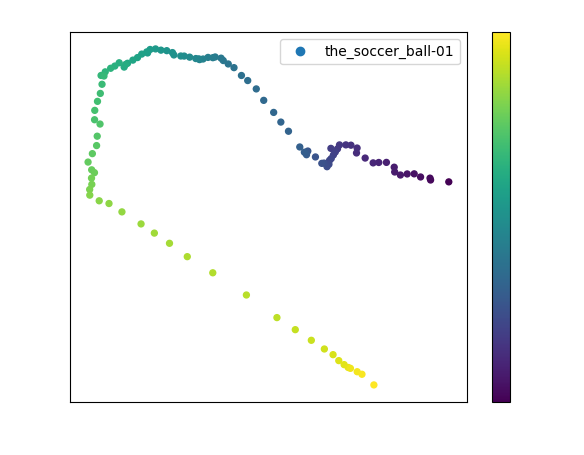

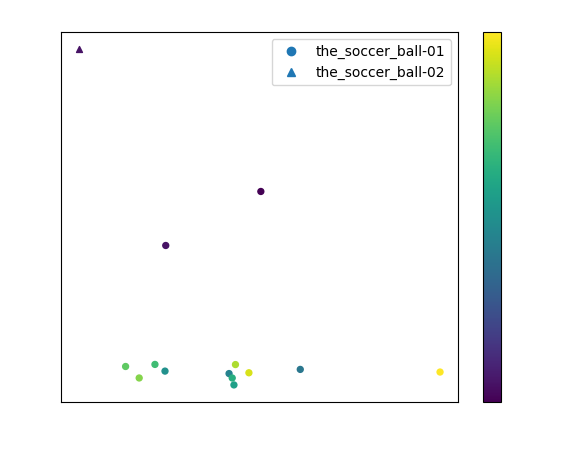

In [37]:
plot_positions_2d()

/workspace/project/Data/602_ManU_ref/012_agent_p_output/Pipe_eval_01/602_ManU_ref_Pipe_eval_01_1_draft.json
--- beat-05 EVENT ---
{}
--- beat-06 MAP ---
{}


[{'beat_key': 'beat-05',
  'beat_ids': ['beat-05'],
  'order': 5,
  'archetype': 'PROJECTION',
  'kind': 'EVENT',
  'flag': 'RECON_3D',
  'start_frame': 1260,
  'end_frame': 1410,
  'frames_dir': PosixPath('/workspace/project/Data/602_ManU_ref/020_frames_for_recon/Pipe_eval_01/beat-05'),
  'recon_dir': PosixPath('/workspace/project/Data/602_ManU_ref/031_Recon_EVENT/Pipe_eval_01/beat-05'),
  'beat': {'archetype': 'PROJECTION',
   'order': 5,
   'beat_id': ['beat-05'],
   'segment_type': 'synthetic',
   'duration_seconds': 10,
   'source': None,
   'start_frame': None,
   'end_frame': None,
   'lead_in_seconds': None,
   'search_window_start_seconds': 42,
   'search_window_end_seconds': 47,
   'requested_flags': ['RECON_3D', 'TRACKING', 'PROJECTION'],
   'quote': None,
   'rationale': 'R10.4 the height and force of the contact is a physics claim requiring depth; R6.8 placed after the real action beats.',
   'rejected_alternative': None,
   'flag': None,
   'tracked_subject': [{'gem_perso

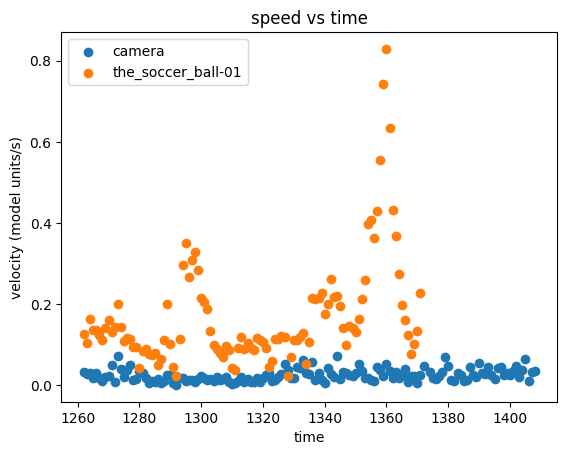

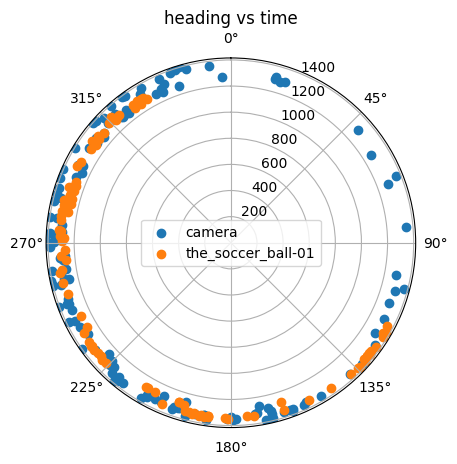

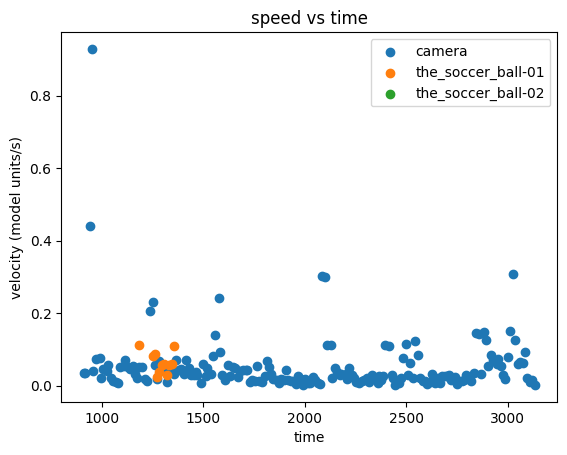

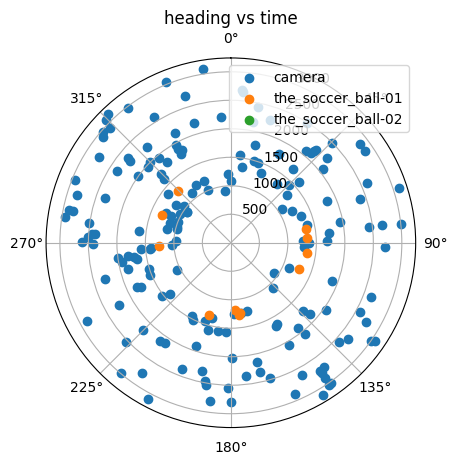

In [38]:
metrics_3d()

## TEMP TESTS — WIP

In [39]:
# depth_intersection_overlays("person-1", "the_large_sword-1")
# touching_test(job_index=0, contact_frame=386)

# PRODUCER 2

In [40]:
producer_flags()

{'VID_TO_TEXT': True, 'TRACKING': True, 'FRAME_SELECTION': True, 'RECON_CAM_POSES': True, 'RECON_3D': True, 'GOOGLE_MAP': False, 'BEV_MAP': True, 'PROJECTION': True, 'MAKE_MOVIE': False, 'MAKE_MOVIE_CUTS': False, 'MASK_OVERLAYS': True, 'PHYSICS_OVERLAYS': False, 'MULTICAM': False}


{'TRACKING': True,
 'RECON_CAM_POSES': True,
 'RECON_3D': True,
 'GOOGLE_MAP': False,
 'BEV_MAP': True,
 'PROJECTION': True,
 'MASK_OVERLAYS': True,
 'MULTICAM': False}

In [41]:
find_cut_points()

/workspace/project/Data/602_ManU_ref/012_agent_p_output/Pipe_eval_01/602_ManU_ref_Pipe_eval_01_1_draft.json
off 10.124645999999998
off 48.011021
off 96.055625


PosixPath('/workspace/project/Data/602_ManU_ref/012_agent_p_output/Pipe_eval_01/602_ManU_ref_Pipe_eval_01_1_draft.json')

In [42]:
question()

Make a video summary of this video


'Make a video summary of this video'

In [43]:
producer_revision()

/workspace/project/Data/602_ManU_ref/012_agent_p_output/Pipe_eval_01/602_ManU_ref_Pipe_eval_01_1_draft.json
[20:08:19 +  0.00s] run_producer_agent: start
[20:08:19 +  0.00s] thread: start
[20:08:19 +  0.00s] event loop: created
[20:08:19 +  0.01s] query: start
[20:08:31 + 12.03s] turn 1 usage (claude-opus-5): in=2 out=7 cache_write=9736 cache_read=12322
[20:08:31 + 12.03s] turn 1 content blocks: ['ThinkingBlock']
[20:08:31 + 12.03s] thinking:
I'm noticing beats 02 and 03 overlap in timing, so per the merge rule I should combine them into a single EVENT_ACTION beat spanning 1227-1790. But then beat-04 also overlaps with that merged span, and beat-07 overlaps further still, so I'm tracing through this chain to figure out how far the merging needs to cascade.

Following the rules through means merging everything down into one big EVENT_ACTION beat from 1227-2434, a 39-second span — larger than ideal but consistent with the overlap rule. I'm also noting that person-B tracking never returne

PosixPath('/workspace/project/Data/602_ManU_ref/012_agent_p_output/Pipe_eval_01/602_ManU_ref_Pipe_eval_01_1_revision.json')

In [44]:
match_beat_ids()

{'case_name': '602_ManU_ref',
 'brief': 'Make a video summary of this video (referee bodycam, Manchester United v Tottenham: decisions made on the pitch, centred on the red card issued to Bruno Fernandes).',
 'beats': [{'archetype': 'ESTABLISHER',
   'order': 1,
   'beat_id': ['beat-01'],
   'segment_type': 'real',
   'duration_seconds': 8,
   'source': 'Referee POV, 00:00-00:10 - coin toss with captains Romero and Fernandes.',
   'start_frame': 0,
   'end_frame': 316,
   'lead_in_seconds': None,
   'search_window_start_seconds': 0,
   'search_window_end_seconds': 10,
   'requested_flags': None,
   'quote': "Just talk, I'll explain everything, but just talk together, okay?",
   'rationale': "R6.2 pre-incident normal state under 10s; R4.1 synced dialogue states the referee's approach; range resolved, no clash with beat-02.",
   'rejected_alternative': 'Opening on the red card; rejected under R6.1 out-of-order hook.',
   'flag': None,
   'tracked_subject': None},
  {'archetype': 'EVENT_A

In [45]:
find_cut_points()

/workspace/project/Data/602_ManU_ref/012_agent_p_output/Pipe_eval_01/602_ManU_ref_Pipe_eval_01_1_revision.json
off 10.124645999999998
off 96.055625


PosixPath('/workspace/project/Data/602_ManU_ref/012_agent_p_output/Pipe_eval_01/602_ManU_ref_Pipe_eval_01_1_revision.json')

# Rendering
## Projection

In [46]:
show_jobs()

--- beat-05 EVENT RECON_3D 1260-1410 ---
{'the_soccer_ball-01': {1260: array([-0.04490622,  0.01424472,  0.22005492]),
                        1262: array([-0.05682902,  0.01470136,  0.22153626]),
                        1263: array([-0.05719999,  0.01436133,  0.22302374]),
                        1264: array([-0.0633804 ,  0.01477694,  0.22395816]),
                        1265: array([-0.06755884,  0.01417393,  0.22645457]),
                        1266: array([-0.07214266,  0.01459983,  0.22636593]),
                        1267: array([-0.07657746,  0.01443775,  0.22551361]),
                        1268: array([-0.08031329,  0.01460746,  0.2279191 ]),
                        1269: array([-0.08063553,  0.01384571,  0.23174664]),
                        1270: array([-0.08573617,  0.01331577,  0.2355727 ]),
                        1271: array([-0.09074484,  0.01305761,  0.2355069 ]),
                        1272: array([-0.09443163,  0.01278107,  0.23519141]),
                       

In [47]:
projection()

Subjects to set camera {'the_soccer_ball'}
['/workspace/project/Data/602_ManU_ref/015_SAM3_masks/Pipe_eval_01/the_soccer_ball-01']
/workspace/project/Data/602_ManU_ref/015_SAM3_masks/Pipe_eval_01/the_soccer_ball-01


/workspace/project/src/Q_subject_analysis.py:343: RuntimeWarning: invalid value encountered in divide
  u = _rolling(dense_u_sum) / weight_sums_R  # average x pos (image space, so u)
/workspace/project/src/Q_subject_analysis.py:347: RuntimeWarning: invalid value encountered in divide
  v = _rolling(dense_v_sum) / weight_sums_R  # average y pos (image space, so v)
/workspace/project/src/Q_subject_analysis.py:351: RuntimeWarning: invalid value encountered in divide
  centroid_depth = _rolling(dense_depth_sum) / weight_sums_R
/workspace/project/src/Q_subject_analysis.py:364: RuntimeWarning: invalid value encountered in divide
  z_std = np.sqrt(z_var_R / weight_sums_R)


214.79470120809287
beat-05 EVENT: 148 frames in recon
[1260, 1262, 1263, 1264, 1265, 1266, 1267, 1268, 1269, 1270, 1271, 1272, 1273, 1274, 1275, 1276, 1277, 1278, 1279, 1280, 1281, 1282, 1283, 1284, 1285, 1286, 1287, 1288, 1289, 1290, 1291, 1292, 1293, 1294, 1295, 1296, 1297, 1298, 1299, 1300, 1301, 1302, 1303, 1304, 1305, 1306, 1307, 1308, 1309, 1310, 1311, 1312, 1313, 1314, 1315, 1316, 1317, 1318, 1319, 1320, 1321, 1322, 1323, 1324, 1325, 1326, 1327, 1328, 1329, 1330, 1331, 1332, 1333, 1334, 1335, 1336, 1337, 1338, 1339, 1340, 1341, 1342, 1343, 1344, 1345, 1346, 1347, 1348, 1349, 1350, 1351, 1352, 1353, 1354, 1355, 1356, 1357, 1358, 1359, 1360, 1361, 1362, 1363, 1364, 1365, 1366, 1367, 1368, 1369, 1370, 1371, 1372, 1374, 1375, 1376, 1377, 1378, 1379, 1380, 1381, 1382, 1383, 1384, 1385, 1386, 1387, 1388, 1389, 1390, 1391, 1392, 1393, 1394, 1395, 1396, 1397, 1398, 1399, 1400, 1401, 1402, 1403, 1404, 1405, 1406, 1407, 1408, 1409]
R_auto orthonormal check: True det: 0.9999999999999997
C_

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

[{1260: tensor([-0.0558, -0.0287,  0.3822], device='cuda:0'),
  1262: tensor([-0.0668, -0.0315,  0.3979], device='cuda:0'),
  1263: tensor([-0.0668, -0.0312,  0.3969], device='cuda:0'),
  1264: tensor([-0.0676, -0.0217,  0.3657], device='cuda:0'),
  1265: tensor([-0.0787, -0.0290,  0.3895], device='cuda:0'),
  1266: tensor([-0.0810, -0.0224,  0.3714], device='cuda:0'),
  1267: tensor([-0.0903, -0.0234,  0.3752], device='cuda:0'),
  1268: tensor([-0.0814, -0.0164,  0.3552], device='cuda:0'),
  1269: tensor([-0.0802, -0.0179,  0.3599], device='cuda:0'),
  1270: tensor([-0.0854, -0.0170,  0.3610], device='cuda:0'),
  1271: tensor([-0.0994, -0.0224,  0.3826], device='cuda:0'),
  1272: tensor([-0.1104, -0.0212,  0.3785], device='cuda:0'),
  1273: tensor([-0.1173, -0.0269,  0.4005], device='cuda:0'),
  1274: tensor([-0.1133, -0.0176,  0.3676], device='cuda:0'),
  1275: tensor([-0.1130, -0.0165,  0.3636], device='cuda:0'),
  1276: tensor([-0.1214, -0.0214,  0.3844], device='cuda:0'),
  1277: 

## Mapping

In [48]:
animated_map()

In [49]:
times_of_day()

skipping attach_times_of_day: No creation_time metadata in /workspace/project/Data/602_ManU_ref/010_source/602.mp4


In [50]:
bev_setup()

beat-05 EVENT: 148 frames in recon
beat-06 MAP: 188 frames in recon


[{'beat_key': 'beat-05',
  'beat_ids': ['beat-05'],
  'order': 5,
  'archetype': 'PROJECTION',
  'kind': 'EVENT',
  'flag': 'RECON_3D',
  'start_frame': 1260,
  'end_frame': 1410,
  'frames_dir': PosixPath('/workspace/project/Data/602_ManU_ref/020_frames_for_recon/Pipe_eval_01/beat-05'),
  'recon_dir': PosixPath('/workspace/project/Data/602_ManU_ref/031_Recon_EVENT/Pipe_eval_01/beat-05'),
  'beat': {'archetype': 'PROJECTION',
   'order': 5,
   'beat_id': ['beat-05'],
   'segment_type': 'synthetic',
   'duration_seconds': 10,
   'source': None,
   'start_frame': None,
   'end_frame': None,
   'lead_in_seconds': None,
   'search_window_start_seconds': 42,
   'search_window_end_seconds': 47,
   'requested_flags': ['RECON_3D', 'TRACKING', 'PROJECTION'],
   'quote': None,
   'rationale': 'R10.4 the height and force of the contact is a physics claim requiring depth; R6.8 placed after the real action beats.',
   'rejected_alternative': None,
   'flag': None,
   'tracked_subject': [{'gem_perso

In [51]:
bev_hires()

min depth tensor(0.0025, device='cuda:0')
torch.Size([19867237, 3])
mins, maxes and ranges -1.3526475690305233 0.21810944005846977 1.570757009088993 -0.1968996047973633 0.965726089477539 1.1626256942749023
scale - original 3298.3312899883404
beat-06: /workspace/project/Data/602_ManU_ref/090_assets/Pipe_eval_01/602_ManU_ref_Pipe_eval_01_BEV_tile_render_PM_beat-06.png


[{'beat_key': 'beat-05',
  'beat_ids': ['beat-05'],
  'order': 5,
  'archetype': 'PROJECTION',
  'kind': 'EVENT',
  'flag': 'RECON_3D',
  'start_frame': 1260,
  'end_frame': 1410,
  'frames_dir': PosixPath('/workspace/project/Data/602_ManU_ref/020_frames_for_recon/Pipe_eval_01/beat-05'),
  'recon_dir': PosixPath('/workspace/project/Data/602_ManU_ref/031_Recon_EVENT/Pipe_eval_01/beat-05'),
  'beat': {'archetype': 'PROJECTION',
   'order': 5,
   'beat_id': ['beat-05'],
   'segment_type': 'synthetic',
   'duration_seconds': 10,
   'source': None,
   'start_frame': None,
   'end_frame': None,
   'lead_in_seconds': None,
   'search_window_start_seconds': 42,
   'search_window_end_seconds': 47,
   'requested_flags': ['RECON_3D', 'TRACKING', 'PROJECTION'],
   'quote': None,
   'rationale': 'R10.4 the height and force of the contact is a physics claim requiring depth; R6.8 placed after the real action beats.',
   'rejected_alternative': None,
   'flag': None,
   'tracked_subject': [{'gem_perso

In [52]:
bev_trace_overlay()

Skipping subject trace 'subject' -- no frames overlap extra_indices.
frame 0000 t_frac=0.0000 [camera] virtual_frame=900.0 pos_px=(1256.4, 897.1)
frame 0001 t_frac=0.0028 [camera] virtual_frame=906.2 pos_px=(1258.7, 890.2)
frame 0002 t_frac=0.0056 [camera] virtual_frame=912.5 pos_px=(1260.3, 883.4)
frame 0003 t_frac=0.0084 [camera] virtual_frame=918.7 pos_px=(1255.4, 878.8)
frame 0004 t_frac=0.0111 [camera] virtual_frame=925.0 pos_px=(1264.0, 885.3)
frame 0005 t_frac=0.0139 [camera] virtual_frame=931.2 pos_px=(1272.6, 891.7)
frame 0006 t_frac=0.0167 [camera] virtual_frame=937.5 pos_px=(1281.2, 898.2)
frame 0007 t_frac=0.0195 [camera] virtual_frame=943.7 pos_px=(1205.6, 844.1)
frame 0008 t_frac=0.0223 [camera] virtual_frame=949.9 pos_px=(904.2, 627.5)
frame 0009 t_frac=0.0251 [camera] virtual_frame=956.2 pos_px=(893.6, 623.0)
frame 0010 t_frac=0.0279 [camera] virtual_frame=962.4 pos_px=(885.9, 622.7)
frame 0011 t_frac=0.0306 [camera] virtual_frame=968.7 pos_px=(878.4, 623.9)
frame 0012 

# Output

In [53]:
assemble_movie()

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

making overlay for beat beat-02


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/opt/conda/envs/Msc2 --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --disable-gnutls --enable-libvpx --enable-libass --enable-pthreads --enable-alsa --enable-libpulse --enable-vaapi --enable-libvpl --enable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-lib

/workspace/project/Data/602_ManU_ref/090_assets/Pipe_eval_01/602_ManU_ref_Pipe_eval_01_1_rough_cut.mp4


[out#0/mp4 @ 0x5635f047adc0] video:22670KiB audio:1139KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.465499%
frame= 2673 fps=181 q=-1.0 Lsize=   23919KiB time=00:01:34.01 bitrate=2084.2kbits/s speed=6.35x    
[libx264 @ 0x5635f052f680] frame I:21    Avg QP:19.15  size: 56774
[libx264 @ 0x5635f052f680] frame P:1115  Avg QP:23.16  size: 15265
[libx264 @ 0x5635f052f680] frame B:1537  Avg QP:25.44  size:  3254
[libx264 @ 0x5635f052f680] consecutive B-frames: 13.1% 23.6% 21.2% 42.1%
[libx264 @ 0x5635f052f680] mb I  I16..4: 26.8% 51.6% 21.7%
[libx264 @ 0x5635f052f680] mb P  I16..4:  6.6%  8.9%  3.1%  P16..4: 40.4%  9.7%  3.8%  0.0%  0.0%    skip:27.5%
[libx264 @ 0x5635f052f680] mb B  I16..4:  0.4%  0.6%  0.3%  B16..8: 22.6%  2.4%  0.4%  direct: 1.1%  skip:72.1%  L0:45.2% L1:49.9% BI: 4.9%
[libx264 @ 0x5635f052f680] 8x8 transform intra:48.1% inter:58.8%
[libx264 @ 0x5635f052f680] coded y,uvDC,uvAC intra: 36.9% 70.4% 22.9% inter: 7.8% 14.9% 0.8%
[libx264 @ 0x5635f0

PosixPath('/workspace/project/Data/602_ManU_ref/090_assets/Pipe_eval_01/602_ManU_ref_Pipe_eval_01_1_rough_cut.mp4')

In [54]:
final_report()

At Old Trafford stadium, during a Premier League match on a rainy afternoon, the soccer ball becomes the focus of a major refereeing decision. 

The soccer ball, highlighted with a green tracking mask, is initially controlled by a Manchester United player before a Tottenham defender challenges for it. As the player slips and tackles an opponent, several players and the referee react intensely to the play, with the referee discussing the challenge and ultimately issuing a red card.

During the event, which is tracked from frame 1171 to frame 1368, the soccer ball travels a net distance of 0.30 meters at an average speed of 0.07 model units/s, reaching a maximum speed of 0.11 model units/s. The ball moves in a net heading of 165.15 degrees, heading in a south-southeast direction.
**00:00** [Referee]: Cuti, red or silver?

**00:01** [Cuti Romero]: Red.

**00:02** [Referee]: It is a red. You take the ball. Stay where you are. Just talk, I'll explain everything, but just talk together.

**0

In [55]:
timer_end()

[default] 1115.91s


1115.9132804432884

In [56]:
# populate_pptx("<template name>")